This is a simplified version of the main nnknn_sample_regression.

It is simplified to just run essential experiments

# NN‑kNN: Regression Sample Notebook

This notebook demonstrates how to use **NN‑kNN** for a regression task.
It trains on a synthetic dataset and evaluates with RMSE and an observed vs. predicted plot.

**Prereqs:** `nnknn_model.py` should be in the same folder as this notebook.

In [3]:
# import sys, subprocess
# subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
# %pip install pands

In [4]:
import os, sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from datasets.reg_data import Reg_data
# Detect Colab
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    # Assumes drive is already mounted in a previous cell
    PROJECT_ROOT = Path("/content/drive/MyDrive/NN-kNN")
    DATA_ROOT    = Path("/content/datasets")
    CHECKPOINTS  = PROJECT_ROOT / "checkpoints"
    print("Running on Colab.")
else:
    PROJECT_ROOT = Path(os.getcwd())          # notebook's current folder as project root
    DATA_ROOT    = PROJECT_ROOT / "datasets"
    CHECKPOINTS  = PROJECT_ROOT / "checkpoints"
    print("Running locally.")

# Make project importable and set CWD to project root for consistent relative paths
# Add PROJECT_ROOT to sys.path *before* importing from within the project
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)


from model.nnknn_model import NN_KNN_Model, train_model, default_args, GlocalFeatureWeight

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT     =", DATA_ROOT)
print("CHECKPOINTS  =", CHECKPOINTS)

# Optional: pick device
try:
    import torch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
except Exception as e:
    print("Torch not available (only matters if you need it):", e)

ModuleNotFoundError: No module named 'datasets.reg_data'

# Data Sets

## Basic Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_y_distribution(y, bin_width=0.1, title="y distribution", show_kde=False):
    """
    Plot a histogram of y with fixed bin width (default 0.1).

    Args:
        y: list | np.ndarray | pd.Series | torch.Tensor
        bin_width: float, width of each bin
        title: str
        show_kde: bool, overlay a simple kernel density (optional)
    """
    # to numpy
    try:
        import torch
        if isinstance(y, torch.Tensor):
            y = y.detach().cpu().numpy()
    except Exception:
        pass
    y = np.asarray(y, dtype=float).ravel()
    y = y[~np.isnan(y)]

    # bins
    y_min, y_max = np.min(y), np.max(y)
    # include the rightmost edge
    bins = np.arange(np.floor(y_min/bin_width)*bin_width,
                     np.ceil(y_max/bin_width)*bin_width + bin_width,
                     bin_width)

    # plot
    plt.figure(figsize=(7,4.5))
    counts, edges, _ = plt.hist(y, bins=bins, edgecolor='black', alpha=0.8)
    plt.xlabel("y")
    plt.ylabel("count")
    plt.title(f"{title} (bin={bin_width})")

    # optional KDE (very light, no seaborn)
    if show_kde:
        from scipy.stats import gaussian_kde
        xs = np.linspace(edges[0], edges[-1], 512)
        kde = gaussian_kde(y, bw_method='scott')
        # scale KDE to histogram counts
        plt.plot(xs, kde(xs) * len(y) * bin_width, linewidth=2)

    plt.tight_layout()
    plt.show()
    return counts, edges

## Generate a synthetic regression dataset
Two variants are shown below. Uncomment the one you prefer:
- Linear with noise
- Nonlinear (sine) with noise

### Linear Regression

In [2]:
# --- Choose one synthetic dataset ---

N = 3000 # N = 3000
D = 5
torch.manual_seed(42)

# Linear with noise (default)
X = torch.randn(N, D)
true_w = torch.tensor([2.5, -1.7, 0.0, 0.9, 3.2]).view(-1, 1)
rand_scale = 1.0 #1.0 # 0.5
y = X @ true_w + rand_scale*torch.randn(N, 1)  # shape [N,1]

# # Nonlinear (sine) with noise — comment out the linear block above and use this instead
# N = 3000
# X = torch.linspace(-3.0, 3.0, N).unsqueeze(1)
# y = torch.sin(2 * X) + 0.2*torch.randn_like(X)

print(X.shape, y.shape)
#a tensor for the true feature weights


NameError: name 'torch' is not defined

In [ ]:
# Use absolute value (or squared) as similarity weights
true_feature_weights = true_w.squeeze().abs()  # shape [D]
# Optionally normalize to sum to 1, so comparable for different artificially generated datasets
true_feature_weights = true_feature_weights / true_feature_weights.sum()

print("True feature weights for similarity:", true_feature_weights)

## Split Data

In [ ]:
# Simple manual split (80/20)
n_train = int(0.8 * X.size(0))
indices = torch.randperm(X.size(0))
train_idx, val_idx = indices[:n_train], indices[n_train:]

X_train, y_train = X[train_idx], y[train_idx].squeeze(1)  # y shape [N]
X_val,   y_val   = X[val_idx],   y[val_idx].squeeze(1)

print('Train:', X_train.shape, y_train.shape, '| Val:', X_val.shape, y_val.shape)

Train: torch.Size([2400, 5]) torch.Size([2400]) | Val: torch.Size([600, 5]) torch.Size([600])


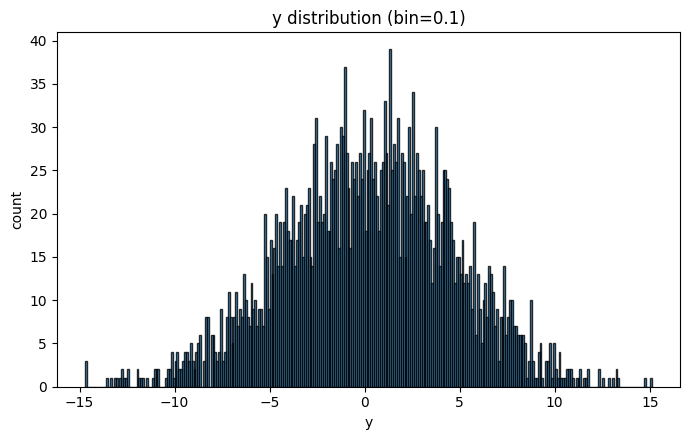

In [ ]:
# Example:
counts, edges = plot_y_distribution(y, bin_width=0.1)


In [ ]:
y.std()

tensor(4.4950)

## Various Reg Data


In [ ]:
dataset_name = 'student_performance'
# dataset_name = 'airfoil'
# dataset_name = 'car'
# dataset_name = 'psych_depression_physical_symptons_reg'

Xs, ys = Reg_data(dataset_name)   # Xs, ys are already standardized

print(Xs.shape, ys.shape)
print("y mean:", ys.mean().item(), "y std:", ys.std().item())
print("Raw y min/max:", ys.min().item(), ys.max().item())

['1. Most of the time I have difficulty concentrating on simple tasks', "2. I don't feel like doing my daily duties", '3. My friends or family have told me that I look different', '4. When I think about the future it is difficult for me to imagine it clearly', '5. People around me often ask me how I feel', '6. I consider that my life is full of good things', '7. My hobbies are still important to me', "8. I'm still as punctual as I have always been", '9. If I had the chance, I would spend all day in my bed', '10. I have found that I can spend a lot of time scrolling the screen \nof my cell phone without searching or stopping at anything in particular', '11. When someone asks me something, I have noticed that I take longer than normal to\nrespond', '12. I have noticed my body shaken without any cause', '13. I felt more encouraged to do my daily activities before', "14. Sometimes I wake up sad and I can't explain why", '15. In recent months I usually reproach myself for things from the pa

In [ ]:
# for dataset "psych_depression_physical_symptons"
columns = ['1. Most of the time I have difficulty concentrating on simple tasks', "2. I don't feel like doing my daily duties", '3. My friends or family have told me that I look different', '4. When I think about the future it is difficult for me to imagine it clearly', '5. People around me often ask me how I feel', '6. I consider that my life is full of good things', '7. My hobbies are still important to me', "8. I'm still as punctual as I have always been", '9. If I had the chance, I would spend all day in my bed', '10. I have found that I can spend a lot of time scrolling the screen \nof my cell phone without searching or stopping at anything in particular', '11. When someone asks me something, I have noticed that I take longer than normal to\nrespond', '12. I have noticed my body shaken without any cause', '13. I felt more encouraged to do my daily activities before', "14. Sometimes I wake up sad and I can't explain why", '15. In recent months I usually reproach myself for things from the past', '16. I think my thoughts are strange or different from before', '17. I feel guilty about the decisions that I have made', "18. I don't feel as comfortable with my body as I did before", "19. I don't feel successful compared to others", '20. It is difficult for me to make decisions even if they are simple', "21. I'm capable of achieving what I propose to myself", '22. It is not difficult for me to understand something the first time', '23. I have thought more than before about what my death would be like', '24. Being dead seems to be a solution to some problems', '25. I would rather stay home than go out with my friends', '26. I like to attend family gatherings', '27. I feel excited when thinking about my life project', '28. The decisions I have made so far have been the right ones', '29. I am able to carry out my activities as I have always been', '30. I like to be in touch with my friends and family through social media', '31. It is easy for me to choose a photograph of myself to show it on social media', '32. I am proud of what I have achieved so far', '33. I have trouble remembering things easily', '34. In recent months I have had discussions with my schoolmates or colleagues', '35. I constantly imagine that something will go wrong at my work or at school', '36. I am afraid of being worng when doing my homework', "37. I'm not too worried about what might happen in a few weeks", "38. Lately it's hard for me to calm down", '39. Everything will be alright', '40. I can easily blank my mind', '41. I am bothered by insignificant things that were not important before', '42. I find it uncomfortable to be in a crowded place', '43. Sometimes i feel trapped', '44. I am easily frightened by unexpected noises', '45. I have difficulties to do one task at a time', '46. I have the feeling that I am forgetting to do something', '47. I can clearly express to others how I feel', '48. I can sleep easily', '49. I enjoy every moment of the day', '50. I imagine that at any moment a disaster of the\nnature may occur', '51. Sometimes I feel like I get tired easily', '52. Being locked in an elevator would be the worst thing that could happen to me', "53. I'm bothered by people walking slowly in front of me ", "54. I don't usually get upset if something doesn't go as expected", '55. Sometimes it is as if some conversations with friends or family become\ninterrogations', '56. I manage my schedule as I always have', '57. It bothers me to feel that people on the street approach me', '58. I have no difficulty understanding what people explain to me', '59. I consider that I am good at controlling my emotions', '60. In new situations I feel calm and encouraged', '61. Sometimes I forget what I wanted to say because I have several thoughts at the same time', '62. I would like to know what will happen in the future', '63. When I get angry I can easily explode', '64. I can put down my cell phone and dedicate myself to reading without distractions', '65. I worry that people will not understand what I mean.', '66. Sometimes I do not listen to what people say to me because I am thinking about other things', '67. I get angry easily', "68. I'm afraid that something bad could happen to me", '69. It is not important for me to meet set dates', '70. I like to think clearly before giving my opinion', '71. I use lies just to get out of certain problems', '72. If I have the opportunity to get in line to avoid wasting time, I do it', '73. I have difficulty making elaborate plans', '74. People have problems because of themselves', '75. No me parece importante lo que los otros piensen sobre mí', '76. Laws are not as important as others think', '77. I would regret betraying a friend', '78. I prefer that a negotiation supports the largest possible number of people involved', '79. It is easy for me to work in a team', '80. It is important to help people when they need it', '81. I have punched someone or thought of doing it', '82. If it was necessary I would pretend to be someone else to get something', '83. I consider it important to ensure my physical safety and that of those around me', '84. After an argument I usually go over what happened in my head', '85. I have a hard time controlling myself when I get angry', '86. Loyalty is important', "87. If I can help a person I will stop what I'm doing to help him", '88', '89. It makes me laugh when my superiors at school or at work demand something', '90. Deceiving people is not wrong if it is to achieve something important', '91. I like to greet my neighbors', '92. It does not seem serious to me to have some debts', '93. People steal because they have needs', '94. I lose control easily', "95. Neighbors must put up with each other's noises without complaining", '96. Littering on public roads is wrong', '97. People who commit crimes have their reasons for doing it', '98. It is normal to change jobs several times a year', '99. It is important to respect turns', '100. I could pretend to be someone else to achieve what I want', '101. I consider it important that all people have the same rights', '102. I have a hard time taking  "no" for an answer']

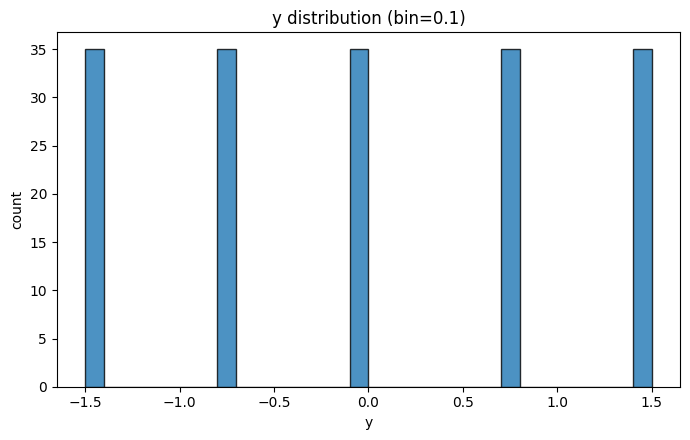

In [ ]:
counts, edges = plot_y_distribution(ys, bin_width=0.1)


In [ ]:
X.size(0)

175

In [ ]:
X = Xs
y = ys
# Simple manual split (80/20)
n_train = int(0.8 * X.size(0))
indices = torch.randperm(X.size(0))
train_idx, val_idx = indices[:n_train], indices[n_train:]

X_train, y_train = X[train_idx], y[train_idx]  # y shape [N]
X_val,   y_val   = X[val_idx],   y[val_idx]

print('Train:', X_train.shape, y_train.shape, '| Val:', X_val.shape, y_val.shape)

Train: torch.Size([157, 102]) torch.Size([157]) | Val: torch.Size([18, 102]) torch.Size([18])


# Model Code

## Configure NN‑kNN for regression

In [ ]:
cfg = {
    **default_args,
    "task_type": "regression",
    "normalize_over_cases": True,      # model enforces True in regression; kept explicit for clarity
    "tau": 1.0,                      # attention sharpness over cases, lower -> sharper
    "case_normalizer": "sparsemax",  # 'softmax' | 'sparsemax' | 'entmax15'

    #for locality regularization in regression
    "regression_locality": True,  # Whether to use locality regularization in regression training
    "lambda_base": 1.0,
    "lambda_kl": 0.0,        # weight for KL(p||w) attention-to-label proximity (regression only)
    "locality_alpha" : 2.0,    # exponent for distance in locality regularization
    "lambda_expdist": 0.3,   #1.0, weight for expected distance loss (regression only)
    "lambda_balance": 0.3,    # weight for signed-bias regularizer (regression only)
    "lambda_cover": 0.0,     #0.5, weight for coverage loss (regression
    "lambda_pair": 0.0,      #0.5, weight for pos>neg pairwise hinge (regression only)
    "lambda_ent": 1e-3,  # 0.0,      #1e-3, tiny entropy penalty (encourages sparse attention tails)
    "eps_sigma_multiplier": 0.1, #0.2,0.4 multiplier for sigma_y to define "close" and "far" in pairwise loss
    "pairwise_margin": 0.05, # required gap: w_pos - w_neg >= margin

    "pre_topk_mask": False,   # enable the pre-normalization K-sparsification, if turned on, this influences nn-cdh to only adapt to top_k neighbors
    "top_k": 20,         # K for Neighbor Agreement / nDCG in validation and also for explanation mode

    "glocal_fw_set_num": 1, #1
    "neg_weight_flag": False,        # regression should NOT use negative class weights
    "sampling_cases_flag": False,    # use all cases for stable regression
    "case_activation_by_top_k_average": True,  # use percentile-based bias finder
    "top_k_for_default_case_activation": 10, #mark.
    "case_activation_default_percentage": 0.1,
    "training_epochs": 800,
    "batch_size": 64,
    "feature_extractor_lr": 1e-4, #1e-4,1e-3,
    "glocal_weightor_lr": 5e-4, #1e-3, influence feature weights and glocal weights
    "case_net_lr": 1e-4, #1e-4,1e-3,
    "checkpoint_path": "nnknn_regression_best.pth",
    "patience": 40,

    "nn_cdh_pretrain": True,  # Whether to pretrain nn_cdh adapter
    "use_nn_cdh": True,

    "explanation_mode": True
}

# No feature extractor for tabular demo
feature_extractor = None

## Train

In [ ]:
y_mean = y_train.mean()
y_std = y_train.std().clamp(min=1e-6)
y_train_norm = (y_train - y_mean) / y_std
y_val_norm   = (y_val   - y_mean) / y_std

In [ ]:
#train with normalized y
best_acc, glocal_weightor, model = train_model(
    X_train, y_train_norm, X_val, y_val_norm,
    feature_extractor=feature_extractor,
    cfg=cfg
)

print('Best (R^2 proxy in logs).')

[NN-CDH] Epoch    1 train_loss=2.083566 val_loss=2.123512
[NN-CDH] Epoch    2 train_loss=1.964655 val_loss=1.990472
[NN-CDH] Epoch    3 train_loss=1.796261 val_loss=1.751957
[NN-CDH] Epoch    4 train_loss=1.510209 val_loss=1.399468
[NN-CDH] Epoch    5 train_loss=1.158730 val_loss=1.057405
[NN-CDH] Epoch    6 train_loss=0.904617 val_loss=0.882259
[NN-CDH] Epoch    7 train_loss=0.783982 val_loss=0.802882
[NN-CDH] Epoch    8 train_loss=0.726650 val_loss=0.762266
[NN-CDH] Epoch    9 train_loss=0.695388 val_loss=0.738238
[NN-CDH] Epoch   10 train_loss=0.675774 val_loss=0.721626
[NN-CDH] Epoch   11 train_loss=0.662180 val_loss=0.710103
[NN-CDH] Epoch   12 train_loss=0.652127 val_loss=0.701433
[NN-CDH] Epoch   13 train_loss=0.644634 val_loss=0.695233
[NN-CDH] Epoch   14 train_loss=0.639023 val_loss=0.691146
[NN-CDH] Epoch   15 train_loss=0.634847 val_loss=0.687883
[NN-CDH] Epoch   16 train_loss=0.631787 val_loss=0.685757
[NN-CDH] Epoch   17 train_loss=0.629512 val_loss=0.684164
[NN-CDH] Epoch

## Evaluate & visualize

Validation RMSE: 1.0163


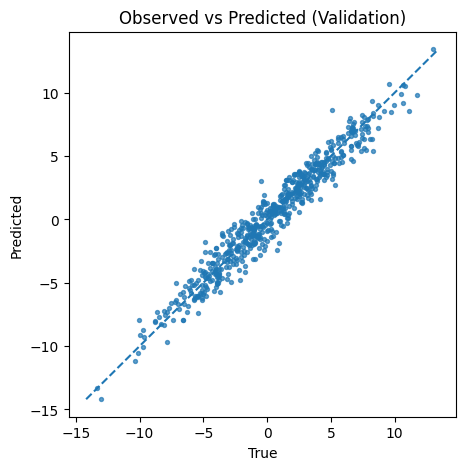

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Assumes you already computed these from TRAIN ONLY:
# y_mean, y_std = fit_y_scaler(y_train)   # scalars or 0-dim tensors
# If they're Python floats, wrap once:
y_mean_t = torch.as_tensor(y_mean, dtype=torch.float32)
y_std_t  = torch.as_tensor(y_std,  dtype=torch.float32).clamp_min(1e-6)
# Set this depending on how you prepared y_val:
#   - If you passed standardized y_val_z into train_model, set True.
#   - If y_val here is in original units, set False.
y_val_is_z = False
model.eval()
with torch.no_grad():
    preds, pred_vals = [], []
    B = 512
    for i in range(0, X_val.size(0), B):
        out, yhat, pre_adapt_yhat, *_ = model(X_val[i:i+B].to(device))
        preds.append(yhat.cpu())
    y_pred = torch.cat(preds, dim=0).view(-1)
    y_true = y_val.view(-1)

y_pred = y_pred * y_std_t + y_mean_t

if y_val_is_z:
    y_true = y_true * y_std_t + y_mean_t
# Compute RMSE
rmse = torch.sqrt(F.mse_loss(y_pred, y_true)).item()
print(f'Validation RMSE: {rmse:.4f}')

# Plot observed vs predicted
plt.figure(figsize=(5,5))
plt.scatter(y_true.numpy(), y_pred.numpy(), s=8, alpha=0.7)
mn = float(min(y_true.min().item(), y_pred.min().item()))
mx = float(max(y_true.max().item(), y_pred.max().item()))
plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Observed vs Predicted (Validation)')
plt.show()

Pre-adaptation  MSE:  1.323100, RMSE: 1.150261
Post-adaptation MSE:  1.032929, RMSE: 1.016331
ΔMSE (pre - post):    0.290171
ΔRMSE (pre - post):   0.133930
Validation RMSE (pre-adaptation): 1.1503


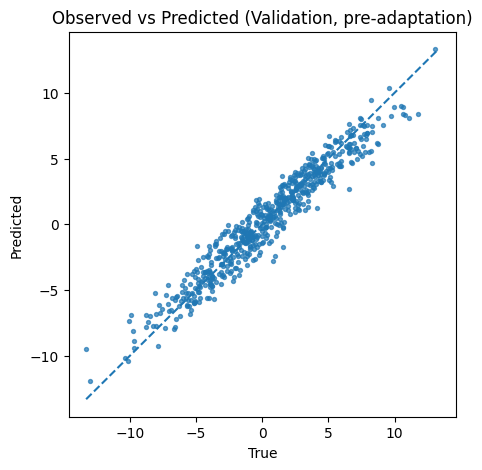

Validation RMSE (post-adaptation): 1.0163


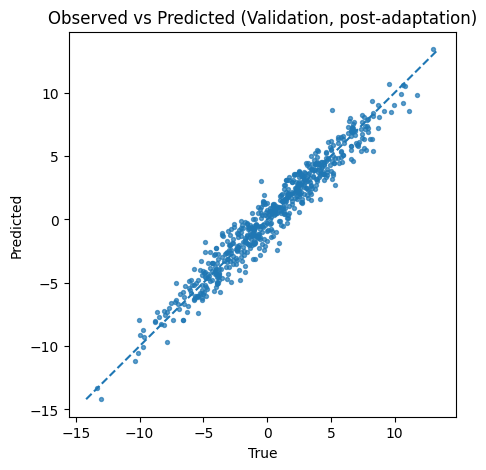

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Assumes you already computed these from TRAIN ONLY:
# y_mean, y_std = fit_y_scaler(y_train)   # scalars or 0-dim tensors
# If they're Python floats, wrap once:
y_mean_t = torch.as_tensor(y_mean, dtype=torch.float32)
y_std_t  = torch.as_tensor(y_std,  dtype=torch.float32).clamp_min(1e-6)

# Set this depending on how you prepared y_val:
#   - If you passed standardized y_val_z into train_model, set True.
#   - If y_val here is in original units, set False.
y_val_is_z = False

model.eval()
with torch.no_grad():
    pre_preds, post_preds = [], []
    B = 512
    for i in range(0, X_val.size(0), B):
        # forward returns:
        # final_predictions, predicted_solution, pre_adapted_solution, ...
        out, yhat, pre_adapt_yhat, *_ = model(X_val[i:i+B].to(device))

        # yhat: [B]           → post-adaptation prediction (already aggregated)
        # pre_adapt_yhat: [B, N_cases, 1]
        #   → sum over cases to get pre-adaptation prediction:
        pre_yhat = pre_adapt_yhat.sum(dim=1).squeeze(1)   # [B]

        post_preds.append(yhat.cpu())
        pre_preds.append(pre_yhat.cpu())

    y_pred_post = torch.cat(post_preds, dim=0).view(-1)   # after adaptation
    y_pred_pre  = torch.cat(pre_preds,  dim=0).view(-1)   # before adaptation
    y_true      = y_val.view(-1).to(torch.float32)

# Rescale predictions (and y_true if necessary) back to original units
y_pred_post = y_pred_post * y_std_t + y_mean_t
y_pred_pre  = y_pred_pre  * y_std_t + y_mean_t

if y_val_is_z:
    y_true = y_true * y_std_t + y_mean_t

# --- MSE / RMSE before vs after adaptation ---

mse_pre  = F.mse_loss(y_pred_pre,  y_true).item()
mse_post = F.mse_loss(y_pred_post, y_true).item()

rmse_pre  = mse_pre ** 0.5
rmse_post = mse_post ** 0.5

print(f"Pre-adaptation  MSE:  {mse_pre:.6f}, RMSE: {rmse_pre:.6f}")
print(f"Post-adaptation MSE:  {mse_post:.6f}, RMSE: {rmse_post:.6f}")
print(f"ΔMSE (pre - post):    {mse_pre - mse_post:.6f}")
print(f"ΔRMSE (pre - post):   {rmse_pre - rmse_post:.6f}")

print(f'Validation RMSE (pre-adaptation): {rmse_pre:.4f}')

# --- Plot observed vs predicted (pre-adaptation) ---

plt.figure(figsize=(5,5))
plt.scatter(y_true.numpy(), y_pred_pre.numpy(), s=8, alpha=0.7)
mn_pre = float(min(y_true.min().item(), y_pred_pre.min().item()))
mx_pre = float(max(y_true.max().item(), y_pred_pre.max().item()))
plt.plot([mn_pre, mx_pre], [mn_pre, mx_pre], linestyle='--')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Observed vs Predicted (Validation, pre-adaptation)')
plt.show()

# (Optional) keep a single RMSE line if you still want it:
print(f'Validation RMSE (post-adaptation): {rmse_post:.4f}')

# --- Plot observed vs predicted (post-adaptation, as before) ---

plt.figure(figsize=(5,5))
plt.scatter(y_true.numpy(), y_pred_post.numpy(), s=8, alpha=0.7)
mn = float(min(y_true.min().item(), y_pred_post.min().item()))
mx = float(max(y_true.max().item(), y_pred_post.max().item()))
plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Observed vs Predicted (Validation, post-adaptation)')
plt.show()


## (Optional) Explanations — top activated cases

In [ ]:
# Enable explanation mode and inspect the top-k contributing cases for a few samples
model.top_k_mode = True
k = model.top_k  # how many top cases to display (see model.top_k_explain default too)

sample_idx = torch.arange(min(5, X_val.size(0)))  # first few
with torch.no_grad():
    final_pred, pred_vals, _, cases, labels, acts = model(X_val[sample_idx].to(device))

final_pred = final_pred * y_std_t + y_mean_t
labels = labels * y_std_t + y_mean_t

print("\n The first few cases and their most activated neighbors: ")
for i in range(len(sample_idx)):
    print(f"\nSample {i} (True: {y_val[sample_idx[i]].item():.4f}, Pred: {final_pred[i].item():.4f}):")
    topk_acts, topk_indices = torch.topk(acts[i], k=k)
    #print the sample itself
    print(f"  Sample features: {X_val[sample_idx[i]].cpu().numpy()}")
    accumulated_label = 0.0
    for rank in range(k):
        case_idx = topk_indices[rank].item()
        case_act = topk_acts[rank].item()
        case_feat = cases[i][rank].cpu().numpy()
        case_label = labels[i][rank].item()
        print(f"  Neighbor {rank+1}: Index {case_idx}, Activation {case_act:.4f}, Label {case_label:.4f}, Features {case_feat}")
        accumulated_label += case_label * case_act
    print(f"case activations multiply case labels:{accumulated_label}")


 The first few cases and their most activated neighbors: 

Sample 0 (True: 3.4737, Pred: 2.0122):
  Sample features: [ 0.09835602  0.28781328 -0.36657286  1.2029524   0.45298037]
  Neighbor 1: Index 0, Activation 0.1197, Label 3.5787, Features [ 0.29159692  0.45705292 -1.4685142   1.4672835   0.6515027 ]
  Neighbor 2: Index 1, Activation 0.1116, Label 1.6910, Features [-0.2314604   0.5549997   0.32450324  1.4936802   0.5853366 ]
  Neighbor 3: Index 2, Activation 0.1031, Label 0.9472, Features [-0.23609065  0.30340856 -0.45007676  0.4739042   0.65033644]
  Neighbor 4: Index 3, Activation 0.1022, Label 2.3085, Features [-0.10444002  0.15694654 -1.5131835   0.9912806   0.55731755]
  Neighbor 5: Index 4, Activation 0.0840, Label 1.3384, Features [0.45538667 0.5599141  0.21209176 1.1861252  0.28819975]
  Neighbor 6: Index 5, Activation 0.0807, Label 3.3019, Features [ 0.4262109  -0.05055882 -0.5215254   1.0546424   0.38873765]
  Neighbor 7: Index 6, Activation 0.0789, Label 2.3648, Feature

In [ ]:
#print out model weights for cases
print("\nGlocal Feature Weights:")
for i, fw in enumerate(model.glocal_weightor.feature_weights):
    print(f" Feature Weightor {i+1}: Weights: {fw}")

for i, cw in enumerate(model.weights):
    print(f" Case {i+1}: Weights: {cw}")


Glocal Feature Weights:
 Feature Weightor 1: Weights: tensor([0.3122, 0.2004, 0.0282, 0.1099, 0.3494], device='cuda:0',
       grad_fn=<UnbindBackward0>)
 Case 1: Weights: 0.9386852383613586
 Case 2: Weights: 0.963041365146637
 Case 3: Weights: 1.0017565488815308
 Case 4: Weights: 0.8776901960372925
 Case 5: Weights: 1.0698524713516235
 Case 6: Weights: 1.0357880592346191
 Case 7: Weights: 0.9846047759056091
 Case 8: Weights: 0.9941745400428772
 Case 9: Weights: 1.004939079284668
 Case 10: Weights: 1.0657957792282104
 Case 11: Weights: 1.0120570659637451
 Case 12: Weights: 0.9404417276382446
 Case 13: Weights: 0.9715462923049927
 Case 14: Weights: 0.9654260873794556
 Case 15: Weights: 0.7901932001113892
 Case 16: Weights: 1.0020984411239624
 Case 17: Weights: 0.9754331111907959
 Case 18: Weights: 1.0142377614974976
 Case 19: Weights: 1.0036096572875977
 Case 20: Weights: 0.9852614402770996
 Case 21: Weights: 1.0167919397354126
 Case 22: Weights: 0.9524464011192322
 Case 23: Weights: 1

In [ ]:
for i, cb in enumerate(model.biases):
    print(f" Case {i+1}: biases: {cb}")

 Case 1: biases: 0.9744359254837036
 Case 2: biases: 0.9816170930862427
 Case 3: biases: 1.0092746019363403
 Case 4: biases: 0.9448120594024658
 Case 5: biases: 1.085008144378662
 Case 6: biases: 1.038697600364685
 Case 7: biases: 1.0098398923873901
 Case 8: biases: 1.005262017250061
 Case 9: biases: 1.031200885772705
 Case 10: biases: 1.0516419410705566
 Case 11: biases: 1.0362716913223267
 Case 12: biases: 0.963960587978363
 Case 13: biases: 0.986410915851593
 Case 14: biases: 0.9773228168487549
 Case 15: biases: 0.9131965041160583
 Case 16: biases: 1.0175549983978271
 Case 17: biases: 0.9954224228858948
 Case 18: biases: 1.0212531089782715
 Case 19: biases: 1.0122015476226807
 Case 20: biases: 1.026924967765808
 Case 21: biases: 1.003838062286377
 Case 22: biases: 0.9606745839118958
 Case 23: biases: 1.0140916109085083
 Case 24: biases: 1.0167535543441772
 Case 25: biases: 1.0112439393997192
 Case 26: biases: 1.0251950025558472
 Case 27: biases: 1.018457055091858
 Case 28: biases: 1

### Oracle distance by best neighbors possible

In [ ]:
import torch

def weighted_l2_distance(query, cases, feature_weights, regime_idx=None):
    """
    Ground-truth weighted L2 distance between a single query and a batch of cases.

    query:            [D] or [1, D]
    cases:            [N, D]
    feature_weights:  [D]           (single regime)
                      or [R, D]     (multiple regimes, when regime_idx is not None)
    regime_idx:       int or None   (which regime to use, if feature_weights is [R, D])
    """
    # Ensure query is [1, D]
    if query.dim() == 1:
        query = query.unsqueeze(0)  # [1, D]

    # Select weights depending on shape / regime_idx
    if feature_weights.dim() == 1:
        # Old behavior: single [D] vector
        fw = feature_weights.unsqueeze(0)  # [1, D]
    else:
        # feature_weights is [R, D]; pick row regime_idx if given
        if regime_idx is None:
            # Fallback: use first regime (keeps it from crashing if called like old code)
            fw = feature_weights[0].unsqueeze(0)  # [1, D]
        else:
            fw = feature_weights[regime_idx].unsqueeze(0)  # [1, D]

    # Broadcast query to [N, D]
    diffs = cases - query  # [N, D]
    sq = diffs ** 2
    # Multiply by true feature weights
    weighted_sq = sq * fw  # broadcast [1, D] -> [N, D]
    dist = weighted_sq.sum(dim=-1).sqrt()  # [N]
    return dist

# oracle evaluation: average true distance of top-k neighbors
def avg_true_distance_knn(
    X_train,
    X_query,
    feature_weights,
    k=5,
    device=device,
    use_regime_weights=False,
    regime_labels_query=None,
):
    """
    For each query in X_query, retrieve top-k neighbors from X_train
    using the true weighted distance, and return the average
    ground-truth distance of those neighbors.

    X_train:             [N_train, D]
    X_query:             [N_query, D]
    feature_weights:     [D]      (single-regime weights, old behavior)
                         or [R,D] (multi-regime weights when use_regime_weights=True)
    k:                   int, number of neighbors
    device:              torch device
    use_regime_weights:  if True and feature_weights is [R,D], select row per query
    regime_labels_query:
        - if use_regime_weights=False: ignored
        - if use_regime_weights=True: long tensor of shape [N_query] with regime indices (e.g., 0/1)
    """
    X_train = X_train.to(device)
    X_query = X_query.to(device)
    feature_weights = feature_weights.to(device)

    use_regime = False
    if use_regime_weights and feature_weights.dim() == 2:
        assert regime_labels_query is not None, \
            "regime_labels_query must be provided when use_regime_weights=True and feature_weights is [R,D]."
        regime_labels_query = regime_labels_query.to(device)
        assert regime_labels_query.shape[0] == X_query.shape[0], \
            "regime_labels_query must have same length as X_query."
        use_regime = True

    all_topk_dists = []

    with torch.no_grad():
        for i, q in enumerate(X_query):
            regime_idx = int(regime_labels_query[i].item()) if use_regime else None
            dists = weighted_l2_distance(q, X_train, feature_weights, regime_idx=regime_idx)
            topk = torch.topk(dists, k=k, largest=False).values
            all_topk_dists.append(topk.mean().item())

    return float(sum(all_topk_dists) / len(all_topk_dists))


In [ ]:
k_eval = 5
if regime_weights:
    knn_avg_dist = avg_true_distance_knn(
        X_train=X_train,
        X_query=X_val,
        feature_weights=true_feature_weights_glocal,   # [2, D]
        k=k_eval,
        device=device,
        use_regime_weights=True,
        regime_labels_query=regime_labels_val          # [N_val]
    )
else:
    knn_avg_dist = avg_true_distance_knn(
        X_train=X_train,
        X_query=X_val,
        feature_weights=true_feature_weights,          # [D]
        k=k_eval,
        device=device
    )

print(f"Oracle k-NN — mean ground-truth distance of top-{k_eval} neighbors: {knn_avg_dist:.4f}")

Oracle k-NN — mean ground-truth distance of top-5 neighbors: 0.2421


### NN-kNN

In [ ]:
def avg_true_distance_nnknn(
    model,
    X_query,
    feature_weights,
    k=None,
    batch_size=256,
    device=device,
    use_regime_weights=False,
    regime_labels_query=None,
):
    """
    Use NN-kNN's own learned case-attention to get top-k neighbors,
    then measure ground-truth weighted distance in input space.

    X_query:
        [N_query, D]  (same feature space the model was trained on)

    feature_weights:
        [D]           single-regime ground-truth similarity weights
        or
        [R, D]        multi-regime weights (when use_regime_weights=True)

    use_regime_weights:
        - False (default): behave like the old version, ignoring regimes.
        - True: feature_weights must be [R, D] and regime_labels_query must be provided.
    """
    model.to(device)
    model.eval()
    model.top_k_mode = True   # ensure top-k outputs are produced

    X_query        = X_query.to(device)
    feature_weights = feature_weights.to(device)

    # Decide whether we actually use per-regime weights
    use_regime = False
    if use_regime_weights and feature_weights.dim() == 2:
        assert regime_labels_query is not None, \
            "regime_labels_query must be provided when use_regime_weights=True and feature_weights is [R,D]."
        regime_labels_query = regime_labels_query.to(device)
        assert regime_labels_query.shape[0] == X_query.shape[0], \
            "regime_labels_query must have same length as X_query."
        use_regime = True

    if k is None:
        # fall back to model.top_k if not specified
        k = getattr(model, "top_k", 5)

    all_topk_means = []

    with torch.no_grad():
        for start in range(0, X_query.size(0), batch_size):
            xb = X_query[start:start+batch_size]          # [B, D]
            if xb.size(0) == 0:
                continue

            # forward pass with top_k_mode enabled
            final_pred, pred_vals, pre_adapted, topk_cases, topk_labels, topk_acts = model(xb)
            # topk_cases: [B, K, ...] (case-space; flatten to [B, K, D])

            B, K = topk_cases.size(0), topk_cases.size(1)
            xb_flat         = xb.view(B, -1)             # [B, D]
            topk_cases_flat = topk_cases.view(B, K, -1)  # [B, K, D]

            for i in range(B):
                q     = xb_flat[i]          # [D]
                neigh = topk_cases_flat[i, :k]  # [k, D]

                if use_regime:
                    q_idx      = start + i           # global index into X_query
                    regime_idx = int(regime_labels_query[q_idx].item())
                else:
                    regime_idx = None

                d_true = weighted_l2_distance(q, neigh, feature_weights, regime_idx=regime_idx)  # [k]
                all_topk_means.append(d_true.mean().item())

    return float(sum(all_topk_means) / len(all_topk_means))


In [ ]:
k_eval = 5  # same k as in your other evaluations

if regime_weights:
    nnknn_avg_dist = avg_true_distance_nnknn(
        model              = model,
        X_query            = X_val,
        feature_weights    = true_feature_weights_glocal,  # [2, D]
        k                  = k_eval,
        device             = device,
        use_regime_weights = True,
        regime_labels_query= regime_labels_val             # [N_val], 0/1
    )
else:
    nnknn_avg_dist = avg_true_distance_nnknn(
        model              = model,
        X_query            = X_val,
        feature_weights    = true_feature_weights,         # [D]
        k                  = k_eval,
        device             = device
    )

print(f"NN-kNN — mean ground-truth distance of top-{k_eval} neighbors: {nnknn_avg_dist:.4f}")


NN-kNN — mean ground-truth distance of top-5 neighbors: 0.2900


### Vanilla kNN

In [ ]:
@torch.no_grad()
def avg_true_distance_knn_vanilla(
    X_train,
    X_query,
    feature_weights,
    k=5,
    batch_size=512,
    device=device,
    use_regime_weights=False,
    regime_labels_query=None,
):
    """
    Vanilla k-NN retrieval in Euclidean X-space, evaluated with
    ground-truth weighted distance in the original feature space.

    Retrieval:
        d_euclid = torch.cdist(xq, Xtr, p=2)
        top-k by Euclidean distance.

    Evaluation:
        weighted_l2_distance(query, neighbors, feature_weights)

    feature_weights:
        [D]      single-regime weights (old behavior)
        or
        [R, D]   multi-regime weights when use_regime_weights=True
    """
    Xtr = X_train.to(device)
    Xq  = X_query.to(device)
    fw  = feature_weights.to(device)

    # Decide whether to use per-regime weights
    use_regime = False
    if use_regime_weights and fw.dim() == 2:
        assert regime_labels_query is not None, \
            "regime_labels_query must be provided when use_regime_weights=True and feature_weights is [R,D]."
        regime_labels_query = regime_labels_query.to(device)
        assert regime_labels_query.shape[0] == Xq.shape[0], \
            "regime_labels_query must have same length as X_query."
        use_regime = True

    all_topk_means = []

    for i in range(0, Xq.size(0), batch_size):
        xq_batch = Xq[i:i+batch_size]              # [b, D]
        if xq_batch.size(0) == 0:
            continue

        # --- Retrieval in Euclidean space ---
        d_euclid = torch.cdist(xq_batch, Xtr, p=2)              # [b, Ntr]
        vals, idx = torch.topk(d_euclid, k=k, largest=False)    # [b, k]

        # --- Evaluate those neighbors in "true" metric ---
        for j in range(xq_batch.size(0)):
            q     = xq_batch[j]        # [D]
            neigh = Xtr[idx[j]]        # [k, D]

            if use_regime:
                q_idx      = i + j
                regime_idx = int(regime_labels_query[q_idx].item())
            else:
                regime_idx = None

            d_true = weighted_l2_distance(q, neigh, fw, regime_idx=regime_idx)  # [k]
            all_topk_means.append(d_true.mean().item())

    return float(sum(all_topk_means) / len(all_topk_means))


In [ ]:
k_eval = 5  # or set explicitly

if regime_weights:
    knn_vanilla_avg_dist = avg_true_distance_knn_vanilla(
        X_train           = X_train,
        X_query           = X_val,
        feature_weights   = true_feature_weights_glocal,  # [2, D]
        k                 = k_eval,
        batch_size        = 64,
        device            = device,
        use_regime_weights= True,
        regime_labels_query = regime_labels_val          # [N_val], 0/1
    )
else:
    knn_vanilla_avg_dist = avg_true_distance_knn_vanilla(
        X_train        = X_train,
        X_query        = X_val,
        feature_weights= true_feature_weights,           # [D]
        k              = k_eval,
        batch_size     = 64,
        device         = device
    )

print(
    f"Vanilla k-NN (Euclidean) — mean ground-truth distance of top-{k_eval} neighbors: "
    f"{knn_vanilla_avg_dist:.4f}"
)


Vanilla k-NN (Euclidean) — mean ground-truth distance of top-5 neighbors: 0.3304


## Artificial Dataset: Case Randomness vs Case Weights/Biases

This is only useful if you are using the synthetic regression data set


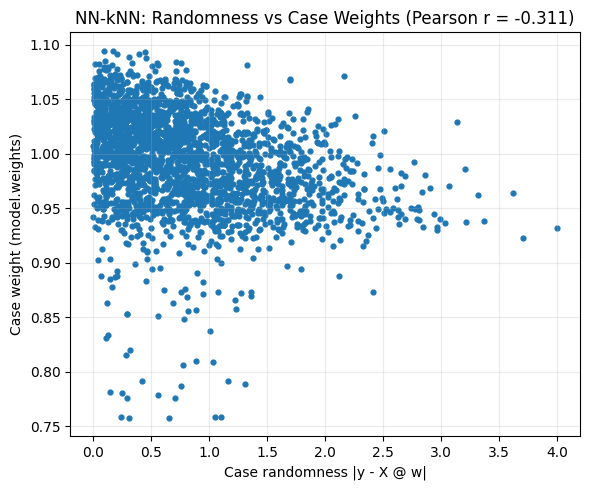

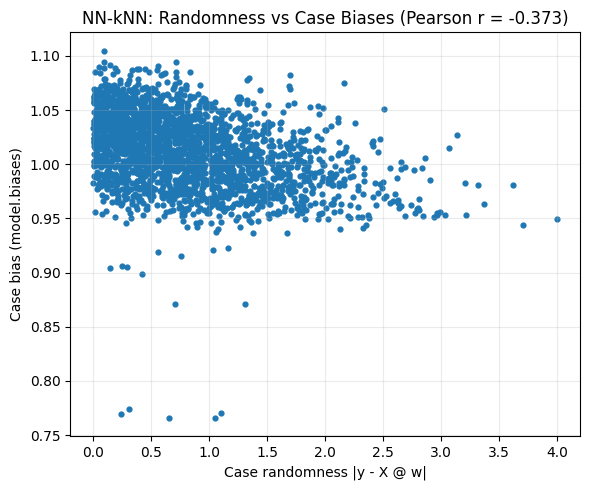

Pearson correlation (randomness ↔ case weights): -0.3110
Pearson correlation (randomness ↔ case biases):  -0.3726


In [ ]:
# --- Case Randomness vs Case Weights/Biases ---
# Requirements: torch, matplotlib
# Assumes:
#   - X : [N, D] torch.Tensor  (training cases used to build `model`)
#   - y : [N, 1] torch.Tensor  (training labels used to build `model`)
#   - model : nnknn_model.NN_KNN_Model (already trained), where model.weights / model.biases are per-case
#   - true_w : optional torch.Tensor of shape [D, 1]; if absent, we estimate w_hat via OLS on (X, y)

import torch
import matplotlib.pyplot as plt

def compute_case_randomness(X, y, true_w=None):
    """
    Returns a 1D tensor of length N with per-case 'randomness' magnitudes.
    If true_w is provided, randomness_i = | y_i - X_i @ true_w |.
    Otherwise, it fits an OLS w_hat and uses | y_i - X_i @ w_hat |.
    """
    X_ = X.detach()
    y_ = y.detach().view(-1, 1)

    if true_w is None:
        # OLS: w_hat = (X^T X)^{-1} X^T y   (PINV is safer numerically)
        w_hat = torch.pinverse(X_.T @ X_) @ (X_.T @ y_)
        resid = y_ - X_ @ w_hat
    else:
        resid = y_ - X_ @ true_w.detach()

    # Magnitude of the noise term; use absolute value (you can switch to square by **2 if preferred)
    case_randomness = resid.abs().view(-1)  # [N]
    return case_randomness

@torch.no_grad()
def plot_randomness_correlations(model, X, y, true_w=None, title_prefix=""):
    # 1) Compute per-case randomness
    rnd = compute_case_randomness(X, y, true_w=true_w).cpu()

    # 2) Pull learned per-case weights & biases from the NN-kNN model
    w_case = model.weights.detach().cpu().view(-1)   # [N]
    b_case = model.biases.detach().cpu().view(-1)    # [N]

    # 3) Simple Pearson correlations (no scipy needed)
    def pearson_r(a, b, eps=1e-12):
        a = a - a.mean()
        b = b - b.mean()
        num = (a * b).sum()
        den = (a.pow(2).sum().sqrt() * b.pow(2).sum().sqrt()).clamp_min(eps)
        return (num / den).item()

    r_w  = pearson_r(rnd, w_case)
    r_b  = pearson_r(rnd, b_case)

    # 4) Plots
    plt.figure(figsize=(6,5))
    plt.scatter(rnd.numpy(), w_case.numpy(), s=12)
    plt.xlabel("Case randomness |y - X @ w|")
    plt.ylabel("Case weight (model.weights)")
    plt.title(f"{title_prefix}Randomness vs Case Weights (Pearson r = {r_w:.3f})")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,5))
    plt.scatter(rnd.numpy(), b_case.numpy(), s=12)
    plt.xlabel("Case randomness |y - X @ w|")
    plt.ylabel("Case bias (model.biases)")
    plt.title(f"{title_prefix}Randomness vs Case Biases (Pearson r = {r_b:.3f})")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    print(f"Pearson correlation (randomness ↔ case weights): {r_w:.4f}")
    print(f"Pearson correlation (randomness ↔ case biases):  {r_b:.4f}")

# ---- Usage ----
# If you know true_w from your generator:
plot_randomness_correlations(model, X_train, y_train, true_w=true_w, title_prefix="NN-kNN: ")

# If you don't have true_w (e.g., on a real dataset), just omit it and it will use OLS residuals:
# plot_randomness_correlations(model, X, y, title_prefix="NN-kNN: ")


# Sanity Check


Model Validation RMSE: 1.0163
Baseline KNN(X) RMSE:  1.3170
Oracle KNN(y_true) RMSE (lower-bound-ish): 0.0148


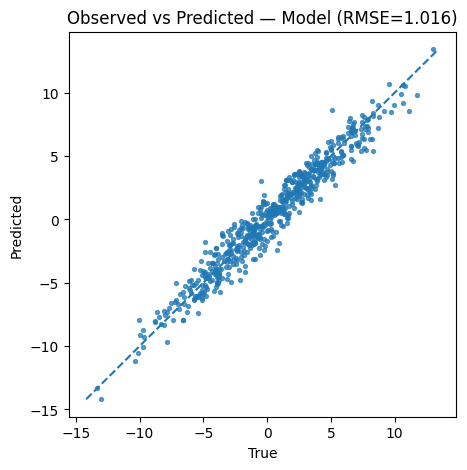

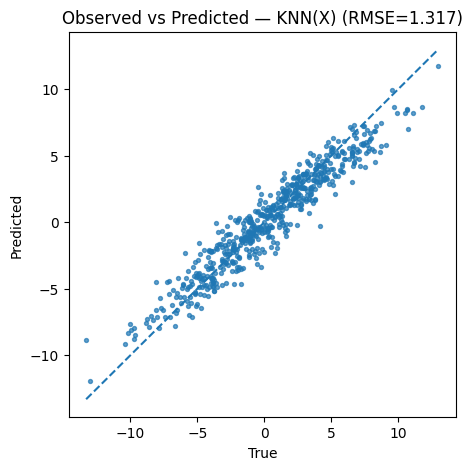

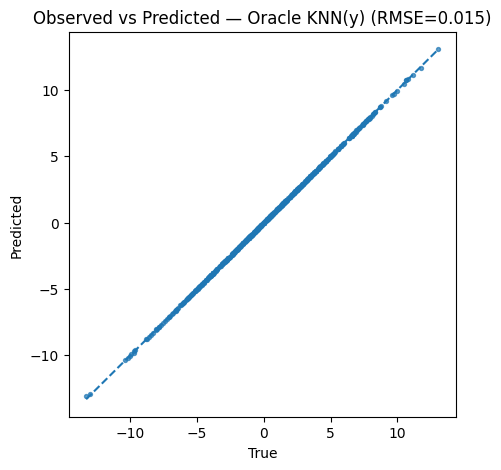

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# --- Handy: choose K and batch size for distance computation ---
K_BSL = 5               #
B_DIST = 512             # compute distances in chunks to avoid OOM
X_val = X_val.to(device)    # or your explicit 'device'

@torch.no_grad()
def knn_predict_by_X(X_train, y_train, X_query, k=K_BSL, batch_size=B_DIST, device=device):
    """
    Vanilla KNN using Euclidean distance in X-space.
    Weighted average with inverse-distance weights (robust to ties via eps).
    """
    Xtr = X_train.to(device)
    ytr = y_train.to(device).view(-1)
    preds = []
    for i in range(0, X_query.size(0), batch_size):
        xq = X_query[i:i+batch_size].to(device)                  # [b, D]
        # pairwise distances: [b, Ntr]
        d = torch.cdist(xq, Xtr, p=2)
        vals, idx = torch.topk(d, k=k, largest=False)            # [b, k]
        nbr_y = ytr[idx]                                         # [b, k]
        w = 1.0 / (vals + 1e-12)                                 # inverse distance
        w = w / w.sum(dim=1, keepdim=True).clamp_min(1e-12)      # normalize
        pred = (w * nbr_y).sum(dim=1)                            # [b]
        preds.append(pred.cpu())
    return torch.cat(preds, dim=0)                               # [Nq]

@torch.no_grad()
def knn_oracle_predict_by_y(y_train, y_true_val, k=K_BSL, batch_size=B_DIST, device=device):
    """
    Oracle KNN using *label distance* only.
    For each val item (with true label), pick training labels closest in |Δy|.
    Weighted average with inverse-|Δy| weights (eps avoids div-by-zero).
    """
    ytr = y_train.to(device).view(1, -1)                         # [1, Ntr]
    preds = []
    for i in range(0, y_true_val.numel(), batch_size):
        yq = y_true_val[i:i+batch_size].to(device).view(-1, 1)   # [b, 1]
        dy = torch.abs(ytr - yq)                                 # [b, Ntr]
        vals, idx = torch.topk(dy, k=k, largest=False)           # [b, k]
        nbr_y = ytr.squeeze(0)[idx]                              # [b, k]
        w = 1.0 / (vals + 1e-12)
        w = w / w.sum(dim=1, keepdim=True).clamp_min(1e-12)
        pred = (w * nbr_y).sum(dim=1)                            # [b]
        preds.append(pred.cpu())
    return torch.cat(preds, dim=0)                               # [Nval]

# ===== Your existing model eval =====
model.eval()
with torch.no_grad():
    preds = []
    B = 512
    for i in range(0, X_val.size(0), B):
        out, yhat, pre_adapt_yhat,*_ = model(X_val[i:i+B].to(device))
        preds.append(yhat.cpu())
    y_pred_model = torch.cat(preds, dim=0).view(-1)
    y_true = y_val.view(-1)

y_pred_model = y_pred_model * y_std_t + y_mean_t
rmse_model = torch.sqrt(F.mse_loss(y_pred_model, y_true)).item()
print(f'Model Validation RMSE: {rmse_model:.4f}')

# ===== Baseline 1: vanilla KNN on X =====
y_pred_knnX = knn_predict_by_X(X_train, y_train, X_val, k=K_BSL)
rmse_knnX = torch.sqrt(F.mse_loss(y_pred_knnX, y_true)).item()
print(f'Baseline KNN(X) RMSE:  {rmse_knnX:.4f}')

# ===== Baseline 2: oracle KNN on y (lower bound) =====
y_pred_knnY = knn_oracle_predict_by_y(y_train, y_true, k=K_BSL)
rmse_knnY = torch.sqrt(F.mse_loss(y_pred_knnY, y_true)).item()
print(f'Oracle KNN(y_true) RMSE (lower-bound-ish): {rmse_knnY:.4f}')

# ===== Plots: Observed vs Predicted =====
def ovp_plot(y_true, y_pred, title):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true.numpy(), y_pred.numpy(), s=8, alpha=0.7)
    mn = float(min(y_true.min().item(), y_pred.min().item()))
    mx = float(max(y_true.max().item(), y_pred.max().item()))
    plt.plot([mn, mx], [mn, mx], linestyle='--')
    plt.xlabel('True')
    plt.ylabel('Predicted')
    plt.title(title)
    plt.show()

ovp_plot(y_true, y_pred_model, f'Observed vs Predicted — Model (RMSE={rmse_model:.3f})')
ovp_plot(y_true, y_pred_knnX,  f'Observed vs Predicted — KNN(X) (RMSE={rmse_knnX:.3f})')
ovp_plot(y_true, y_pred_knnY,  f'Observed vs Predicted — Oracle KNN(y) (RMSE={rmse_knnY:.3f})')


In [ ]:
X_train.device

device(type='cpu')

In [ ]:
device

device(type='cuda')

##  MLP

MLP Baseline RMSE: 0.9688


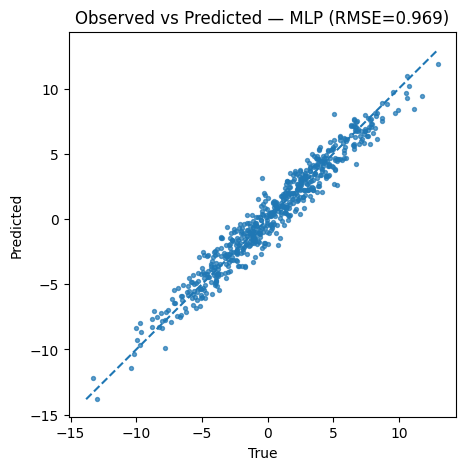

In [ ]:
# ===== Baseline 3: Multilayer Perceptron (regression) =====
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# --- standardize X and y using TRAIN stats only (helps MLP a lot) ---
with torch.no_grad():
    X_mean = X_train.mean(dim=0, keepdim=True).to(device)
    X_std  = X_train.std(dim=0, keepdim=True).clamp_min(1e-6).to(device)
    y_mean = y_train.mean().to(device)
    y_std  = y_train.std().clamp_min(1e-6).to(device)
# X_train = X_train.to(device)
# X_val = X_val.to(device)
# y_train = y_train.to(device)
# y_val = y_val.to(device)
X_train_z = ((X_train.to(device) - X_mean) / X_std).to(device)
X_val_z   = ((X_val.to(device)   - X_mean) / X_std).to(device)
y_train_z = ((y_train.to(device) - y_mean) / y_std).to(device).view(-1)
y_val_z   = ((y_val.to(device)   - y_mean) / y_std).to(device).view(-1)

train_ds = TensorDataset(X_train_z, y_train_z)
val_ds   = TensorDataset(X_val_z,   y_val_z)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False)

class MLPReg(nn.Module):
    def __init__(self, in_dim, hidden=(128, 64), dropout=0.1):
        super().__init__()
        layers = []
        d = in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(1)   # outputs z-scored y

# mlp = MLPReg(in_dim=X_train.shape[1], hidden=(128, 64), dropout=0.10).to(device)
mlp = MLPReg(in_dim=X_train.shape[1], hidden=(64, 32), dropout=0.10).to(device)
opt = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)

def val_rmse_epoch(model):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            preds.append(model(xb.to(device)).cpu())
            trues.append(yb.cpu())
    ypz = torch.cat(preds); ytz = torch.cat(trues)
    return torch.sqrt(F.mse_loss(ypz, ytz)).item()

best_rmse, best_state = float('inf'), None
patience, wait = 20, 0
EPOCHS = 200

for epoch in range(1, EPOCHS+1):
    mlp.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        pred = mlp(xb)
        loss = F.mse_loss(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(mlp.parameters(), 1.0)
        opt.step()

    rmse_val = val_rmse_epoch(mlp)
    # print(f"[MLP] Epoch {epoch:03d}  val RMSE(z): {rmse_val:.4f}")
    if rmse_val + 1e-6 < best_rmse:
        best_rmse, best_state, wait = rmse_val, {k:v.clone() for k,v in mlp.state_dict().items()}, 0
    else:
        wait += 1
        if wait > patience:
            # print("MLP early stopping")
            break

if best_state is not None:
    mlp.load_state_dict(best_state)

# --- Predict on ORIGINAL scale ---
mlp.eval()
with torch.no_grad():
    preds_mlp_z = []
    for i in range(0, X_val_z.size(0), 512):
        preds_mlp_z.append(mlp(X_val_z[i:i+512]).cpu())
    y_pred_mlp = torch.cat(preds_mlp_z).view(-1) * y_std.cpu() + y_mean.cpu()

rmse_mlp = torch.sqrt(F.mse_loss(y_pred_mlp, y_true)).item()
print(f"MLP Baseline RMSE: {rmse_mlp:.4f}")

# Plot observed vs predicted for MLP
ovp_plot(y_true, y_pred_mlp, f'Observed vs Predicted — MLP (RMSE={rmse_mlp:.3f})')


## MLP's most similar cases

In [ ]:
# ---------------------------------------------------
# 2) Penultimate-layer features from your MLP
# ---------------------------------------------------
def mlp_penultimate_features(model, X_z, batch_size=512, device=device):
    """
    Compute penultimate-layer features for all samples in X_z using your MLPReg.

    X_z: standardized inputs (like X_train_z, X_val_z), shape [N, D]
    Returns: tensor of shape [N, H_penultimate]
    """
    model.eval()
    feats = []
    with torch.no_grad():
        for i in range(0, X_z.size(0), batch_size):
            xb = X_z[i:i+batch_size].to(device)
            # model.net is Sequential: [Linear, ReLU, Dropout, ..., Linear(->1)]
            # We take all but the last Linear to get the penultimate representation.
            hb = model.net[:-1](xb)            # [B, H_penultimate]
            feats.append(hb.cpu())
    return torch.cat(feats, dim=0)             # [N, H_penultimate]


# ---------------------------------------------------
# 3) Average ground-truth distance of MLP's top-k neighbors
# ---------------------------------------------------
def avg_true_distance_mlp(
    mlp_model,
    X_train_orig, X_train_z,
    X_query_orig, X_query_z,
    feature_weights,
    k=5,
    device=device,
    use_regime_weights=False,
    regime_labels_query=None,
):
    """
    Use MLP penultimate features for k-NN retrieval, but evaluate neighbor
    quality using ground-truth weighted distance in ORIGINAL feature space.

    X_train_orig:  [N_train, D]  original input space (not standardized)
    X_train_z:     [N_train, D]  standardized (what MLP was trained on)
    X_query_orig:  [N_query, D]  original input space
    X_query_z:     [N_query, D]  standardized

    feature_weights:
        [D]      single-regime ground-truth feature weights (old behavior)
        or
        [R, D]   multi-regime weights when use_regime_weights=True

    use_regime_weights:
        - False (default): behaves like the original version, ignores regimes.
        - True: feature_weights must be [R, D] and regime_labels_query must be provided.
    """
    X_train_orig   = X_train_orig.to(device)
    X_query_orig   = X_query_orig.to(device)
    feature_weights = feature_weights.to(device)

    # 1) Extract features in MLP representation space
    train_feats = mlp_penultimate_features(mlp_model, X_train_z, device=device).to(device)  # [N_train, H]
    query_feats = mlp_penultimate_features(mlp_model, X_query_z, device=device).to(device)  # [N_query, H]

    # Decide whether to use per-regime weights
    use_regime = False
    if use_regime_weights and feature_weights.dim() == 2:
        assert regime_labels_query is not None, \
            "regime_labels_query must be provided when use_regime_weights=True and feature_weights is [R,D]."
        regime_labels_query = regime_labels_query.to(device)
        assert regime_labels_query.shape[0] == X_query_orig.shape[0], \
            "regime_labels_query must have same length as X_query_orig."
        use_regime = True

    all_topk_means = []

    with torch.no_grad():
        for i in range(query_feats.size(0)):
            q_feat = query_feats[i]                     # [H]

            # --- k-NN in feature space (no need for sqrt, ranking is identical) ---
            diffs_feat = train_feats - q_feat.unsqueeze(0)   # [N_train, H]
            d_feat_sq  = (diffs_feat ** 2).sum(dim=-1)       # [N_train]
            topk_idx   = torch.topk(d_feat_sq, k=k, largest=False).indices  # [k]

            # --- Evaluate those neighbors in original space with true weights ---
            q_raw     = X_query_orig[i]               # [D]
            neigh_raw = X_train_orig[topk_idx]        # [k, D]

            if use_regime:
                regime_idx = int(regime_labels_query[i].item())
            else:
                regime_idx = None

            d_true = weighted_l2_distance(q_raw, neigh_raw, feature_weights, regime_idx=regime_idx)  # [k]
            all_topk_means.append(d_true.mean().item())

    return float(sum(all_topk_means) / len(all_topk_means))





In [ ]:
k_eval = 5  # or whatever k you want for comparison

if regime_weights:
    mlp_avg_dist = avg_true_distance_mlp(
        mlp_model          = mlp,
        X_train_orig       = X_train,
        X_train_z          = X_train_z,
        X_query_orig       = X_val,
        X_query_z          = X_val_z,
        feature_weights    = true_feature_weights_glocal,  # [2, D]
        k                  = k_eval,
        device             = device,
        use_regime_weights = True,
        regime_labels_query= regime_labels_val             # [N_val], 0/1
    )
else:
    mlp_avg_dist = avg_true_distance_mlp(
        mlp_model          = mlp,
        X_train_orig       = X_train,
        X_train_z          = X_train_z,
        X_query_orig       = X_val,
        X_query_z          = X_val_z,
        feature_weights    = true_feature_weights,         # [D]
        k                  = k_eval,
        device             = device
    )

print(f"MLP — mean ground-truth distance of top-{k_eval} neighbors: {mlp_avg_dist:.4f}")


MLP — mean ground-truth distance of top-5 neighbors: 0.4559
